### sources:
https://github.com/Blaizzy/mlx-vlm?tab=readme-ov-file#supported-models <br>
https://huggingface.co/mlx-community <br>
https://github.com/ml-explore/mlx-lm <br>

In [1]:
import mlx.core as mx
from mlx_vlm import load, generate
from mlx_vlm.prompt_utils import apply_chat_template
from mlx_vlm.utils import load_config
from PIL import Image as Im
from IPython import display
from IPython.display import display
from tqdm import tqdm
from dotenv import load_dotenv
import os
import regex as re
from time import sleep

/Users/tom/Fine-arts-ML/Fine-Arts-Main/.venv3_12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load environment variables from .env file
load_dotenv()

# Database connection details
cache_dir = './live_pic'
working_dir = os.getcwd()
full_path = os.path.realpath(cache_dir)
image_cache_list = os.listdir(cache_dir)
image_list = []
for pic in image_cache_list:
    pic_path = os.path.join(cache_dir, pic)
    image_list.append(pic_path)

image_list

['./live_pic/florals Kopie 4zu3.jpg']

In [3]:
# Load the model
model_path = "mlx-community/pixtral-12b-bf16"
model, processor = load(model_path)
config = load_config(model_path)

Fetching 13 files: 100%|██████████| 13/13 [00:00<00:00, 108401.50it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Fetching 13 files: 100%|██████████| 13/13 [00:00<00:00, 138390.74it/s]


Processing image 1 of 1
GenerationResult(text='**Produktbeschreibung:**\n\n**Titel:** „Frühlingserwachen“\n\n**Künstler:** Art Heroes\n\n**Medium:** Digitales Aquarell\n\n**Größe:** 16" x 20" (40,64 cm x 50,8 cm)\n\n**Details:**\n\n- **Farben:** Dieses Kunstwerk ist eine lebhafte Feier der Frühlingssaison, die eine Palette aus zarten Pinks, warmen Gelb- und Orangetönen sowie erfrischendem Grün präsentiert. Die Farben sind weich und fließend, was ein Gefühl von Ruhe und Frische erzeugt.\n- **Stimmung:** „Frühlingserwachen“ fängt die Essenz der Erneuerung und des Wachstums ein, die mit dem Frühling verbunden sind. Die weichen, fließenden Pinselstriche schaffen eine Atmosphäre der Gelassenheit und des Optimismus.\n- **Gefühle:** Dieses Kunstwerk lädt den Betrachter ein, die Schönheit der Natur zu schätzen und die Freude zu empfinden, die mit dem Aufblühen der Blumen und dem Erwachen der Natur verbunden ist. Es ist ideal für diejenigen, die', token=1828, logprobs=array([-31.9923, -31.9935,

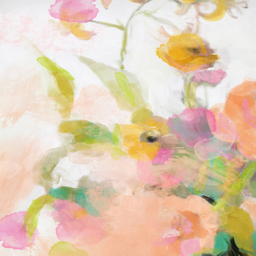

 -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  - 


In [ ]:
regex_pattern = r"(?:text=')(.*)(?=\',)"
i = 0
for pic_url in image_list:
    i += 1
    print(f"Processing image {i} of {len(image_list)}")
    sleep(1)  # Optional: sleep to avoid overwhelming the model with requests?
    image = Im.open(pic_url)
    image_smol = image.resize((256, 256))
    PROMPT = "Beschreibe das Bild für einen online shop ( Art Heroes), gehe auf gefühle, farben und stimmung ein, interpretiere nicht zu viel in die formen."
    formatted_prompt = apply_chat_template(processor, config, PROMPT, num_images=1)
    output = generate(model, processor, formatted_prompt, image, verbose=False)
    relevant_output = re.findall(regex_pattern, str(output))
    print(output)
    #print("Relevant Output:")
    #print(relevant_output)
    display(image_smol)
    print( ' - ' * 50)

Processing image 1 of 1
GenerationResult(text='1. Frühlingsblumen\n2. Pastellfarben\n3. Weiche Pinselstriche\n4. Blühende Natur\n5. Rosa und Gelb\n6. Einfühlsam\n7. Fröhlich\n8. Aquarell\n9. Blumenarrangement\n10. Zarte Töne\n11. Optimistisch\n12. Naturverbunden\n13. Pastellblumen\n14. Gelassene Stimmung\n15. Künstlerisches Blumenbild', token=2, logprobs=array([-25.7103, -25.711, -0.135548, ..., -24.8057, -20.9074, -23.9246], dtype=float32), prompt_tokens=3245, generation_tokens=111, total_tokens=3356, prompt_tps=216.04729811837285, generation_tps=2.0850488139770675, peak_memory=32.869136421)
Relevant Output:
['1. Frühlingsblumen\\n2. Pastellfarben\\n3. Weiche Pinselstriche\\n4. Blühende Natur\\n5. Rosa und Gelb\\n6. Einfühlsam\\n7. Fröhlich\\n8. Aquarell\\n9. Blumenarrangement\\n10. Zarte Töne\\n11. Optimistisch\\n12. Naturverbunden\\n13. Pastellblumen\\n14. Gelassene Stimmung\\n15. Künstlerisches Blumenbild']


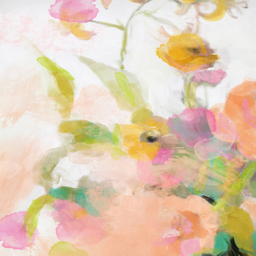

 -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  - 


In [7]:
regex_pattern = r"(?:text=')(.*)(?=\',)"
i = 0
for pic_url in image_list:
    i += 1
    print(f"Processing image {i} of {len(image_list)}")
    sleep(1)  # Optional: sleep to avoid overwhelming the model with requests?
    image = Im.open(pic_url)
    image_smol = image.resize((256, 256))
    PROMPT = "Erstelle Tags für das Bild, die in einem online shop ( Art Heroes) verwendet werden können, gehe auf gefühle, farben und stimmung ein, interpretiere nicht zu viel in die formen."
    formatted_prompt = apply_chat_template(processor, config, PROMPT, num_images=1)
    output = generate(model, processor, formatted_prompt, image, verbose=False)
    relevant_output = re.findall(regex_pattern, str(output))
    print(output)
    print("Relevant Output:")
    print(relevant_output)
    display(image_smol)
    print( ' - ' * 50)